Connected to Python (pygpu-env) (Python 3.11.8)

Using cuda with 1 GPU(s) available.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

<ipython-input-1-ab967fb1a542>:191: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
<ipython-input-1-ab967fb1a542>:203: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...
Epoch 0100/1500 | Overfit L1 Loss: 0.058674
Epoch 0200/1500 | Overfit L1 Loss: 0.030391
Epoch 0300/1500 | Overfit L1 Loss: 0.026191
Epoch 0400/1500 | Overfit L1 Loss: 0.025160
Epoch 0500/1500 | Overfit L1 Loss: 0.019599
Epoch 0600/1500 | Overfit L1 Loss: 0.019083
Epoch 0700/1500 | Overfit L1 Loss: 0.015004
Epoch 0800/1500 | Overfit L1 Loss: 0.014677
Epoch 0900/1500 | Overfit L1 Loss: 0.013781
Epoch 1000/1500 | Overfit L1 Loss: 0.012824
Epoch 1100/1500 | Overfit L1 Loss: 0.013308
Epoch 1200/1500 | Overfit L1 Loss: 0.011604
Epoch 1300/1500 | Overfit L1 Loss: 0.010053
Epoch 1400/1500 | Overfit L1 Loss: 0.010241
Epoch 1500/1500 | Overfit L1 Loss: 0.012340

Generating Validation Gallery...


AttributeError: 'DeltaContinuousModel' object has no attribute 'module'

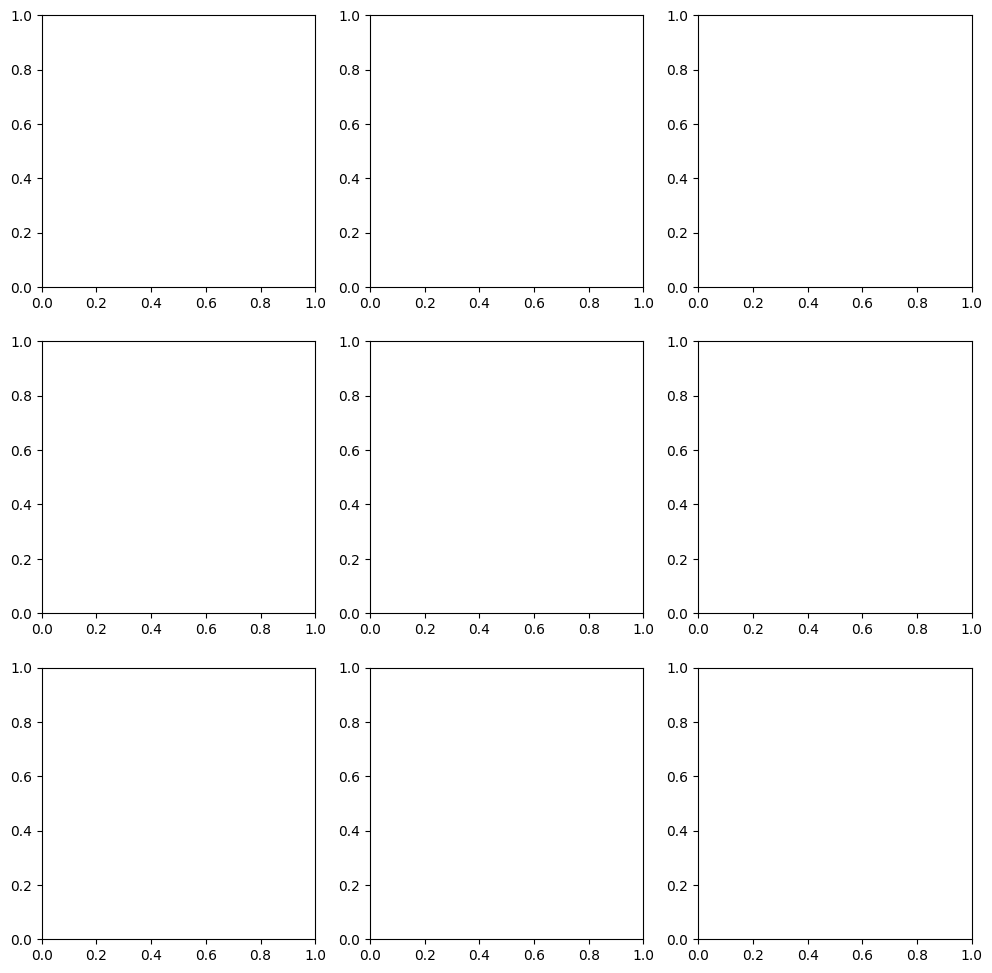

In [ ]:
import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np
from dcm import DeltaContinuousModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {device} with {num_gpus} GPU(s) available.")

# ==========================================
# 1. SYNTHETIC VECTOR DATASET GENERATOR
# ==========================================
def generate_circle(cx=0.5, cy=0.5, r=0.3, segments=20, t=0.03, a=0.8):
    strokes = []
    for i in range(segments):
        theta1 = 2 * math.pi * i / segments
        theta2 = 2 * math.pi * (i + 1) / segments
        x1, y1 = cx + r * math.cos(theta1), cy + r * math.sin(theta1)
        x2, y2 = cx + r * math.cos(theta2), cy + r * math.sin(theta2)
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes

def generate_polygon(n_sides, cx=0.5, cy=0.5, r=0.3, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(n_sides):
        theta = 2 * math.pi * i / n_sides
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(n_sides):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n_sides]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes

def generate_star(cx=0.5, cy=0.5, r_outer=0.3, r_inner=0.12, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(10):
        r = r_outer if i % 2 == 0 else r_inner
        theta = math.pi / 2 + i * math.pi / 5
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(10):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % 10]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes

def generate_perfect_synthetic_dataset(filepath="overfit_dataset.json"):
    t = 0.05 
    a = 1.0 
    data = [
        {"prompt": "Draw a horizontal line", "strokes": [[0.2, 0.5, 0.8, 0.5, t, a]]},
        {"prompt": "Draw a plus sign", "strokes": [[0.5, 0.2, 0.5, 0.8, t, a], [0.2, 0.5, 0.8, 0.5, t, a]]},
        {"prompt": "Draw a square", "strokes": [[0.2, 0.2, 0.8, 0.2, t, a], [0.8, 0.2, 0.8, 0.8, t, a], [0.8, 0.8, 0.2, 0.8, t, a], [0.2, 0.8, 0.2, 0.2, t, a]]},
        {"prompt": "Draw a triangle", "strokes": [[0.5, 0.2, 0.8, 0.8, t, a], [0.8, 0.8, 0.2, 0.8, t, a], [0.2, 0.8, 0.5, 0.2, t, a]]},
        {"prompt": "Draw an X shape", "strokes": [[0.2, 0.2, 0.8, 0.8, t, a], [0.8, 0.2, 0.2, 0.8, t, a]]},
        {"prompt": "Draw a circle", "strokes": generate_circle()},
        {"prompt": "Draw a star", "strokes": generate_star(t=t, a=a)},
        {"prompt": "Draw a hexagon", "strokes": generate_polygon(6, t=t, a=a)},
    ]
    with open(filepath, "w") as f:
        json.dump(data, f, indent=4)


# ==========================================
# 2. CONTINUOUS & RELATIVE DATASET PIPELINE
# ==========================================
class OverfitStrokeDataset(Dataset):
    def __init__(self, json_path, max_seq_len=20):
        with open(json_path, "r") as f:
            self.data = json.load(f)
        self.max_seq_len = max_seq_len
        
        all_rel_strokes = []
        self.processed_data = []
        
        for item in self.data:
            strokes = torch.tensor(item["strokes"], dtype=torch.float32)
            strokes = self.sort_strokes_greedily(strokes)
            rel_strokes = self.to_relative(strokes)
            
            all_rel_strokes.append(rel_strokes)
            self.processed_data.append((item["prompt"], rel_strokes))
            
        # FIX: Calculate Z-Score Normalization Statistics
        concat_strokes = torch.cat(all_rel_strokes, dim=0)
        self.mean = concat_strokes.mean(dim=0)
        self.std = concat_strokes.std(dim=0) + 1e-6 

    def sort_strokes_greedily(self, strokes):
        """FIX: Sorts strokes to maintain a continuous, physical drawing path."""
        if len(strokes) <= 1:
            return strokes
            
        # Start top-left
        dists_to_origin = strokes[:, 0]**2 + strokes[:, 1]**2
        start_idx = torch.argmin(dists_to_origin).item()

        unvisited = list(range(len(strokes)))
        sorted_strokes = []

        curr_idx = start_idx
        while unvisited:
            unvisited.remove(curr_idx)
            sorted_strokes.append(strokes[curr_idx])
            if not unvisited:
                break
            
            curr_end_x, curr_end_y = strokes[curr_idx][2], strokes[curr_idx][3]
            best_dist = float('inf')
            next_idx = unvisited[0]
            
            # Find the unvisited stroke closest to the current pen position
            for idx in unvisited:
                sx, sy = strokes[idx][0], strokes[idx][1]
                dist = (sx - curr_end_x)**2 + (sy - curr_end_y)**2
                if dist < best_dist:
                    best_dist = dist
                    next_idx = idx
            curr_idx = next_idx

        return torch.stack(sorted_strokes)

    def to_relative(self, strokes):
        """FIX: Convert Absolute Coordinates to Relative Offsets"""
        rel_strokes = torch.zeros_like(strokes)
        prev_x, prev_y = 0.0, 0.0
        for i in range(len(strokes)):
            x1, y1, x2, y2, w, a = strokes[i]
            dx1 = x1 - prev_x
            dy1 = y1 - prev_y
            dx2 = x2 - x1
            dy2 = y2 - y1
            rel_strokes[i] = torch.tensor([dx1, dy1, dx2, dy2, w, a])
            prev_x, prev_y = x2, y2
        return rel_strokes

    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        prompt, rel_strokes = self.processed_data[idx]
        
        # Apply Normalization
        norm_strokes = (rel_strokes - self.mean) / self.std

        if norm_strokes.shape[0] > self.max_seq_len:
            norm_strokes = norm_strokes[: self.max_seq_len]
        elif norm_strokes.shape[0] < self.max_seq_len:
            pad_len = self.max_seq_len - norm_strokes.shape[0]
            padding = torch.zeros((pad_len, 6), dtype=torch.float32)
            norm_strokes = torch.cat([norm_strokes, padding], dim=0)

        return prompt, norm_strokes

def to_absolute(rel_strokes):
    """Utility to convert relative deltas back to canvas coordinates."""
    abs_strokes = torch.zeros_like(rel_strokes)
    prev_x, prev_y = 0.0, 0.0
    for i in range(len(rel_strokes)):
        dx1, dy1, dx2, dy2, w, a = rel_strokes[i]
        x1 = prev_x + dx1
        y1 = prev_y + dy1
        x2 = x1 + dx2
        y2 = y1 + dy2
        abs_strokes[i] = torch.tensor([x1, y1, x2, y2, w, a])
        prev_x, prev_y = x2, y2
    return abs_strokes


# ==========================================
# 3. OVERFIT TRAINING LOOP
# ==========================================
def train_overfit(model, dataloader, epochs=1000):
    # FIX: Swap MSE for L1 Loss to prevent averaging geometric uncertainty
    criterion = nn.L1Loss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4
    )
    scaler = GradScaler()

    model.train()
    print("Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...")

    for epoch in range(epochs):
        optimizer.zero_grad()
        total_loss = 0.0

        for prompts, targets in dataloader:
            targets = targets.to(device)

            with autocast():
                predictions = model(prompts, targets)
                loss = criterion(predictions, targets)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:04d}/{epochs} | Overfit L1 Loss: {total_loss/len(dataloader):.6f}")


# ==========================================
# 4. N x 3 GALLERY GENERATOR
# ==========================================
def generate_validation_gallery(model, dataset, prompts, max_strokes=20, cols=3):
    model.eval()
    rows = math.ceil(len(prompts) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    print("\nGenerating Validation Gallery...")

    # Load Normalization Stats to Device
    mean = dataset.mean.to(device)
    std = dataset.std.to(device)

    with torch.no_grad():
        for idx, prompt in enumerate(prompts):
            text_inputs = model.module.tokenizer(
                [prompt], padding=True, return_tensors="pt"
            ).to(device)
            encoder_outputs = model.module.text_encoder(**text_inputs)
            encoder_hidden_states = encoder_outputs.last_hidden_state
            
            cls_token = encoder_hidden_states[:, 0, :]
            context_embed = model.module.text_projection(cls_token).unsqueeze(1)

            current_strokes = torch.zeros((1, 0, 6), device=device)

            for step in range(max_strokes):
                if current_strokes.size(1) > 0:
                    stroke_embeds = model.module.stroke_embedding(current_strokes)
                    decoder_inputs = torch.cat([context_embed, stroke_embeds], dim=1)
                else:
                    decoder_inputs = context_embed

                decoder_inputs = model.module.pos_encoder(decoder_inputs)
                tgt_mask = model.module.generate_causal_mask(decoder_inputs.size(1), device)

                hidden_states = model.module.transformer_decoder(
                    tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
                )

                next_stroke_pred = model.module.output_head(hidden_states[:, -1:, :])
                current_strokes = torch.cat([current_strokes, next_stroke_pred], dim=1)

            # Un-normalize & Convert Relatives to Absolutes
            unnormalized_strokes = (current_strokes.squeeze(0) * std) + mean
            generated_vectors = to_absolute(unnormalized_strokes.cpu()).numpy()

            ax = axes[idx]
            ax.set_xlim(0, 1)
            ax.set_ylim(1, 0)
            ax.set_title(prompt[:30], fontsize=10)

            for stroke in generated_vectors:
                x1, y1, x2, y2, thickness, opacity = stroke
                if opacity > 0.3: 
                    lw = max(1.0, thickness * 15.0)
                    ax.plot(
                        [x1, x2], [y1, y2],
                        color="black", alpha=min(1.0, max(0.0, float(opacity))),
                        linewidth=lw, solid_capstyle="round"
                    )
            ax.axis("off")

    for idx in range(len(prompts), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    generate_perfect_synthetic_dataset()
    dataset = OverfitStrokeDataset("overfit_dataset.json", max_seq_len=20)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
    
    model = DeltaContinuousModel().to(device)
    if num_gpus > 1:
        model = nn.DataParallel(model)

    train_overfit(model, dataloader, epochs=1500)

    test_prompts = [
        "Draw a horizontal line",
        "Draw a plus sign",
        "Draw a square",
        "Draw a triangle",
        "Draw an X shape",
        "Draw a circle",
        "Draw a star",
        "Draw a hexagon",
    ]
    generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)

In [ ]:
# ==========================================
# 4. N x 3 GALLERY GENERATOR
# ==========================================
def generate_validation_gallery(model, dataset, prompts, max_strokes=20, cols=3):
    model.eval()

    # Handle DataParallel wrapping
    actual_model = model.module if isinstance(model, nn.DataParallel) else model

    rows = math.ceil(len(prompts) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    print("\nGenerating Validation Gallery...")

    # Load Normalization Stats to Device
    mean = dataset.mean.to(device)
    std = dataset.std.to(device)

    with torch.no_grad():
        for idx, prompt in enumerate(prompts):
            text_inputs = actual_model.tokenizer(
                [prompt], padding=True, return_tensors="pt"
            ).to(device)
            encoder_outputs = actual_model.text_encoder(**text_inputs)
            encoder_hidden_states = encoder_outputs.last_hidden_state

            cls_token = encoder_hidden_states[:, 0, :]
            context_embed = actual_model.text_projection(cls_token).unsqueeze(1)

            current_strokes = torch.zeros((1, 0, 6), device=device)

            for step in range(max_strokes):
                if current_strokes.size(1) > 0:
                    stroke_embeds = actual_model.stroke_embedding(current_strokes)
                    decoder_inputs = torch.cat([context_embed, stroke_embeds], dim=1)
                else:
                    decoder_inputs = context_embed

                decoder_inputs = actual_model.pos_encoder(decoder_inputs)
                tgt_mask = actual_model.generate_causal_mask(
                    decoder_inputs.size(1), device
                )

                hidden_states = actual_model.transformer_decoder(
                    tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
                )

                next_stroke_pred = actual_model.output_head(hidden_states[:, -1:, :])
                current_strokes = torch.cat([current_strokes, next_stroke_pred], dim=1)

            # Un-normalize & Convert Relatives to Absolutes
            unnormalized_strokes = (current_strokes.squeeze(0) * std) + mean
            generated_vectors = to_absolute(unnormalized_strokes.cpu()).numpy()

            ax = axes[idx]
            ax.set_xlim(0, 1)
            ax.set_ylim(1, 0)
            ax.set_title(prompt[:30], fontsize=10)

            for stroke in generated_vectors:
                x1, y1, x2, y2, thickness, opacity = stroke
                if opacity > 0.3:
                    lw = max(1.0, thickness * 15.0)
                    ax.plot(
                        [x1, x2],
                        [y1, y2],
                        color="black",
                        alpha=min(1.0, max(0.0, float(opacity))),
                        linewidth=lw,
                        solid_capstyle="round",
                    )
            ax.axis("off")

    for idx in range(len(prompts), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


Generating Validation Gallery...


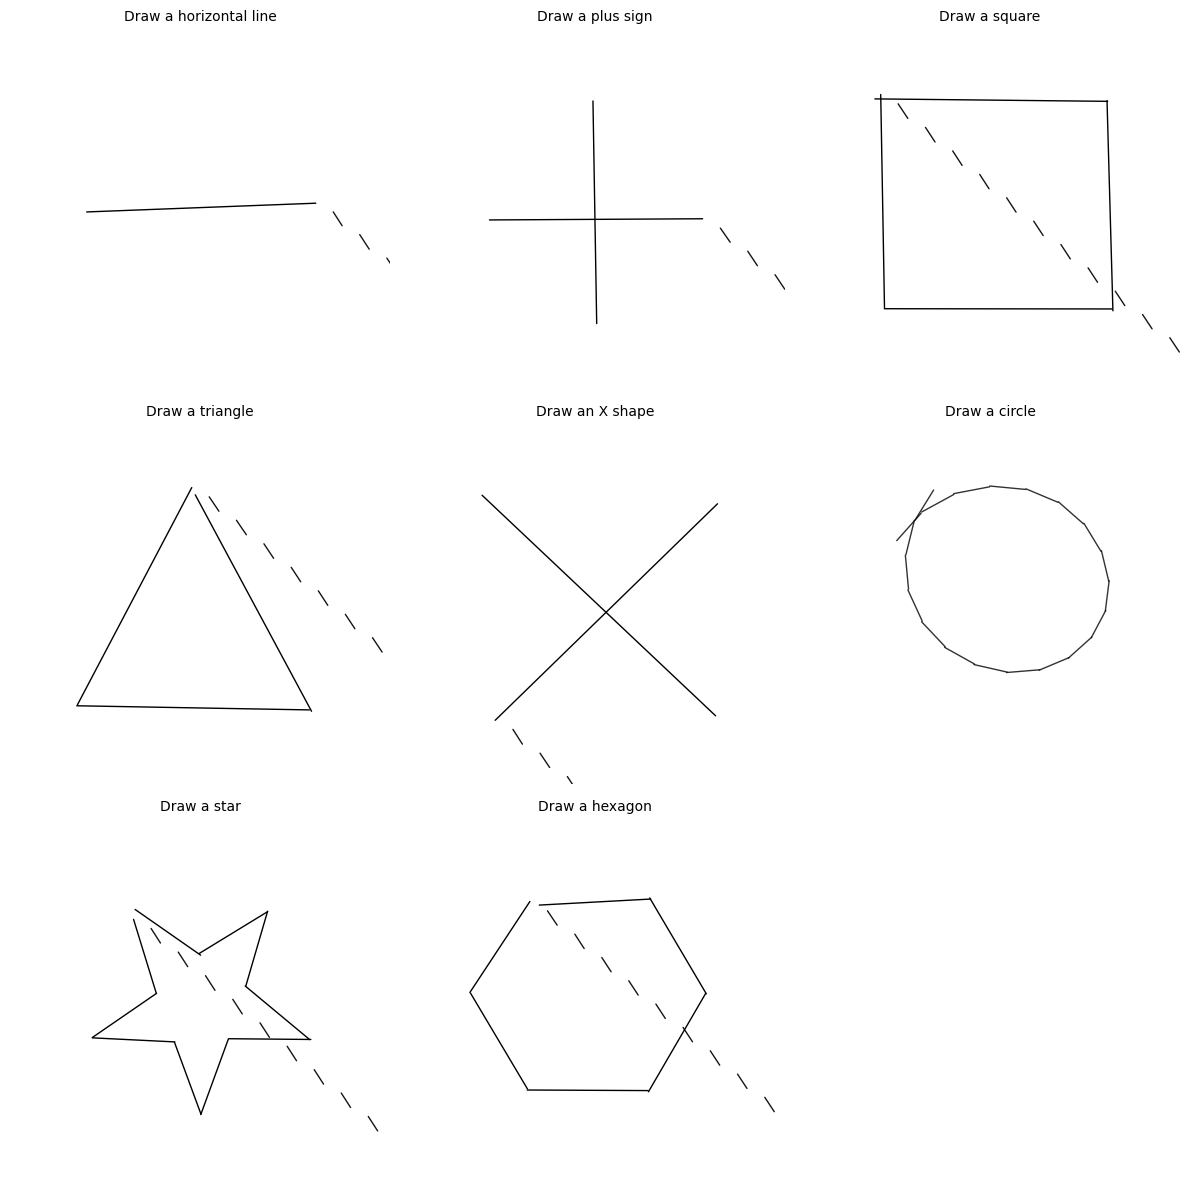

In [ ]:
test_prompts = [
    "Draw a horizontal line",
    "Draw a plus sign",
    "Draw a square",
    "Draw a triangle",
    "Draw an X shape",
    "Draw a circle",
    "Draw a star",
    "Draw a hexagon",
]
generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)

Using cuda with 1 GPU(s) available.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

<ipython-input-4-37c0cc0a1a07>:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
<ipython-input-4-37c0cc0a1a07>:229: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...
Epoch 0100/1500 | Overfit L1 Loss: 0.073433
Epoch 0200/1500 | Overfit L1 Loss: 0.036830
Epoch 0300/1500 | Overfit L1 Loss: 0.038966
Epoch 0400/1500 | Overfit L1 Loss: 0.019282
Epoch 0500/1500 | Overfit L1 Loss: 0.020144
Epoch 0600/1500 | Overfit L1 Loss: 0.016780
Epoch 0700/1500 | Overfit L1 Loss: 0.016685
Epoch 0800/1500 | Overfit L1 Loss: 0.013257
Epoch 0900/1500 | Overfit L1 Loss: 0.012567
Epoch 1000/1500 | Overfit L1 Loss: 0.012070
Epoch 1100/1500 | Overfit L1 Loss: 0.013013
Epoch 1200/1500 | Overfit L1 Loss: 0.012586
Epoch 1300/1500 | Overfit L1 Loss: 0.011221
Epoch 1400/1500 | Overfit L1 Loss: 0.012089
Epoch 1500/1500 | Overfit L1 Loss: 0.010813

Generating Validation Gallery...


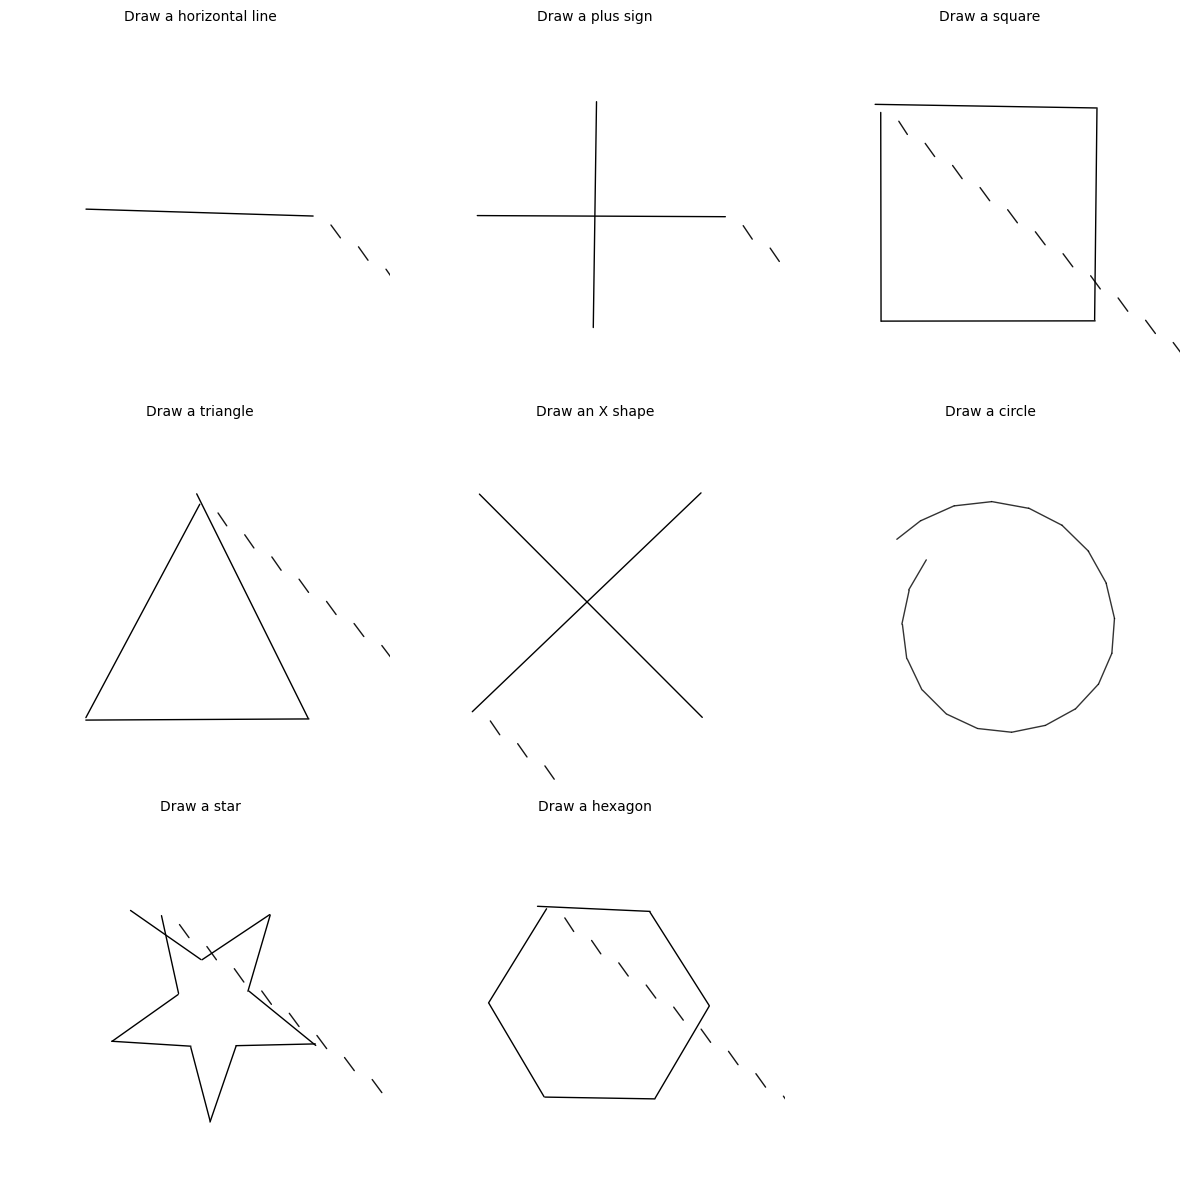

In [ ]:
import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np
from dcm import DeltaContinuousModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {device} with {num_gpus} GPU(s) available.")


# ==========================================
# 1. SYNTHETIC VECTOR DATASET GENERATOR
# ==========================================
def generate_circle(cx=0.5, cy=0.5, r=0.3, segments=20, t=0.03, a=0.8):
    strokes = []
    for i in range(segments):
        theta1 = 2 * math.pi * i / segments
        theta2 = 2 * math.pi * (i + 1) / segments
        x1, y1 = cx + r * math.cos(theta1), cy + r * math.sin(theta1)
        x2, y2 = cx + r * math.cos(theta2), cy + r * math.sin(theta2)
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_polygon(n_sides, cx=0.5, cy=0.5, r=0.3, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(n_sides):
        theta = 2 * math.pi * i / n_sides
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(n_sides):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n_sides]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_star(cx=0.5, cy=0.5, r_outer=0.3, r_inner=0.12, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(10):
        r = r_outer if i % 2 == 0 else r_inner
        theta = math.pi / 2 + i * math.pi / 5
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(10):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % 10]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_perfect_synthetic_dataset(filepath="overfit_dataset.json"):
    t = 0.05
    a = 1.0
    data = [
        {"prompt": "Draw a horizontal line", "strokes": [[0.2, 0.5, 0.8, 0.5, t, a]]},
        {
            "prompt": "Draw a plus sign",
            "strokes": [[0.5, 0.2, 0.5, 0.8, t, a], [0.2, 0.5, 0.8, 0.5, t, a]],
        },
        {
            "prompt": "Draw a square",
            "strokes": [
                [0.2, 0.2, 0.8, 0.2, t, a],
                [0.8, 0.2, 0.8, 0.8, t, a],
                [0.8, 0.8, 0.2, 0.8, t, a],
                [0.2, 0.8, 0.2, 0.2, t, a],
            ],
        },
        {
            "prompt": "Draw a triangle",
            "strokes": [
                [0.5, 0.2, 0.8, 0.8, t, a],
                [0.8, 0.8, 0.2, 0.8, t, a],
                [0.2, 0.8, 0.5, 0.2, t, a],
            ],
        },
        {
            "prompt": "Draw an X shape",
            "strokes": [[0.2, 0.2, 0.8, 0.8, t, a], [0.8, 0.2, 0.2, 0.8, t, a]],
        },
        {"prompt": "Draw a circle", "strokes": generate_circle()},
        {"prompt": "Draw a star", "strokes": generate_star(t=t, a=a)},
        {"prompt": "Draw a hexagon", "strokes": generate_polygon(6, t=t, a=a)},
    ]
    with open(filepath, "w") as f:
        json.dump(data, f, indent=4)


# ==========================================
# 2. CONTINUOUS & RELATIVE DATASET PIPELINE
# ==========================================
class OverfitStrokeDataset(Dataset):
    def __init__(self, json_path, max_seq_len=20):
        with open(json_path, "r") as f:
            self.data = json.load(f)
        self.max_seq_len = max_seq_len

        all_rel_strokes = []
        self.processed_data = []

        for item in self.data:
            strokes = torch.tensor(item["strokes"], dtype=torch.float32)
            strokes = self.sort_strokes_greedily(strokes)
            rel_strokes = self.to_relative(strokes)

            all_rel_strokes.append(rel_strokes)
            self.processed_data.append((item["prompt"], rel_strokes))

        # FIX: Calculate Z-Score Normalization Statistics
        concat_strokes = torch.cat(all_rel_strokes, dim=0)
        self.mean = concat_strokes.mean(dim=0)
        self.std = concat_strokes.std(dim=0) + 1e-6

    def sort_strokes_greedily(self, strokes):
        """FIX: Sorts strokes to maintain a continuous, physical drawing path."""
        if len(strokes) <= 1:
            return strokes

        # Start top-left
        dists_to_origin = strokes[:, 0] ** 2 + strokes[:, 1] ** 2
        start_idx = torch.argmin(dists_to_origin).item()

        unvisited = list(range(len(strokes)))
        sorted_strokes = []

        curr_idx = start_idx
        while unvisited:
            unvisited.remove(curr_idx)
            sorted_strokes.append(strokes[curr_idx])
            if not unvisited:
                break

            curr_end_x, curr_end_y = strokes[curr_idx][2], strokes[curr_idx][3]
            best_dist = float("inf")
            next_idx = unvisited[0]

            # Find the unvisited stroke closest to the current pen position
            for idx in unvisited:
                sx, sy = strokes[idx][0], strokes[idx][1]
                dist = (sx - curr_end_x) ** 2 + (sy - curr_end_y) ** 2
                if dist < best_dist:
                    best_dist = dist
                    next_idx = idx
            curr_idx = next_idx

        return torch.stack(sorted_strokes)

    def to_relative(self, strokes):
        """FIX: Convert Absolute Coordinates to Relative Offsets"""
        rel_strokes = torch.zeros_like(strokes)
        prev_x, prev_y = 0.0, 0.0
        for i in range(len(strokes)):
            x1, y1, x2, y2, w, a = strokes[i]
            dx1 = x1 - prev_x
            dy1 = y1 - prev_y
            dx2 = x2 - x1
            dy2 = y2 - y1
            rel_strokes[i] = torch.tensor([dx1, dy1, dx2, dy2, w, a])
            prev_x, prev_y = x2, y2
        return rel_strokes

    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        prompt, rel_strokes = self.processed_data[idx]

        # Apply Normalization
        norm_strokes = (rel_strokes - self.mean) / self.std

        if norm_strokes.shape[0] > self.max_seq_len:
            norm_strokes = norm_strokes[: self.max_seq_len]
        elif norm_strokes.shape[0] < self.max_seq_len:
            pad_len = self.max_seq_len - norm_strokes.shape[0]
            padding = torch.zeros((pad_len, 6), dtype=torch.float32)
            norm_strokes = torch.cat([norm_strokes, padding], dim=0)

        return prompt, norm_strokes


def to_absolute(rel_strokes):
    """Utility to convert relative deltas back to canvas coordinates."""
    abs_strokes = torch.zeros_like(rel_strokes)
    prev_x, prev_y = 0.0, 0.0
    for i in range(len(rel_strokes)):
        dx1, dy1, dx2, dy2, w, a = rel_strokes[i]
        x1 = prev_x + dx1
        y1 = prev_y + dy1
        x2 = x1 + dx2
        y2 = y1 + dy2
        abs_strokes[i] = torch.tensor([x1, y1, x2, y2, w, a])
        prev_x, prev_y = x2, y2
    return abs_strokes


# ==========================================
# 3. OVERFIT TRAINING LOOP
# ==========================================
def train_overfit(model, dataloader, epochs=1000):
    # FIX: Swap MSE for L1 Loss to prevent averaging geometric uncertainty
    criterion = nn.L1Loss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4
    )
    scaler = GradScaler()

    model.train()
    print("Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...")

    for epoch in range(epochs):
        optimizer.zero_grad()
        total_loss = 0.0

        for prompts, targets in dataloader:
            targets = targets.to(device)

            with autocast():
                predictions = model(prompts, targets)
                loss = criterion(predictions, targets)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1:04d}/{epochs} | Overfit L1 Loss: {total_loss/len(dataloader):.6f}"
            )


# ==========================================
# 4. N x 3 GALLERY GENERATOR
# ==========================================
def generate_validation_gallery(model, dataset, prompts, max_strokes=20, cols=3):
    model.eval()

    # Handle DataParallel wrapping
    actual_model = model.module if isinstance(model, nn.DataParallel) else model

    rows = math.ceil(len(prompts) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    print("\nGenerating Validation Gallery...")

    # Load Normalization Stats to Device
    mean = dataset.mean.to(device)
    std = dataset.std.to(device)

    with torch.no_grad():
        for idx, prompt in enumerate(prompts):
            text_inputs = actual_model.tokenizer(
                [prompt], padding=True, return_tensors="pt"
            ).to(device)
            encoder_outputs = actual_model.text_encoder(**text_inputs)
            encoder_hidden_states = encoder_outputs.last_hidden_state

            cls_token = encoder_hidden_states[:, 0, :]
            context_embed = actual_model.text_projection(cls_token).unsqueeze(1)

            current_strokes = torch.zeros((1, 0, 6), device=device)

            for step in range(max_strokes):
                if current_strokes.size(1) > 0:
                    stroke_embeds = actual_model.stroke_embedding(current_strokes)
                    decoder_inputs = torch.cat([context_embed, stroke_embeds], dim=1)
                else:
                    decoder_inputs = context_embed

                decoder_inputs = actual_model.pos_encoder(decoder_inputs)
                tgt_mask = actual_model.generate_causal_mask(
                    decoder_inputs.size(1), device
                )

                hidden_states = actual_model.transformer_decoder(
                    tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
                )

                next_stroke_pred = actual_model.output_head(hidden_states[:, -1:, :])
                current_strokes = torch.cat([current_strokes, next_stroke_pred], dim=1)

            # Un-normalize & Convert Relatives to Absolutes
            unnormalized_strokes = (current_strokes.squeeze(0) * std) + mean
            generated_vectors = to_absolute(unnormalized_strokes.cpu()).numpy()

            ax = axes[idx]
            ax.set_xlim(0, 1)
            ax.set_ylim(1, 0)
            ax.set_title(prompt[:30], fontsize=10)

            for stroke in generated_vectors:
                x1, y1, x2, y2, thickness, opacity = stroke
                if opacity > 0.3:
                    lw = max(1.0, thickness * 15.0)
                    ax.plot(
                        [x1, x2],
                        [y1, y2],
                        color="black",
                        alpha=min(1.0, max(0.0, float(opacity))),
                        linewidth=lw,
                        solid_capstyle="round",
                    )
            ax.axis("off")

    for idx in range(len(prompts), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


# ==========================================
# 5. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    generate_perfect_synthetic_dataset()
    dataset = OverfitStrokeDataset("overfit_dataset.json", max_seq_len=20)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=False)

    model = DeltaContinuousModel().to(device)
    if num_gpus > 1:
        model = nn.DataParallel(model)

    train_overfit(model, dataloader, epochs=1500)

    test_prompts = [
        "Draw a horizontal line",
        "Draw a plus sign",
        "Draw a square",
        "Draw a triangle",
        "Draw an X shape",
        "Draw a circle",
        "Draw a star",
        "Draw a hexagon",
    ]
    generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)

Connected to Python (pygpu-env) (Python 3.11.8)

Using cuda with 1 GPU(s) available.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

<ipython-input-1-6ac2713db115>:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
<ipython-input-1-6ac2713db115>:231: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...
Epoch 0100/1500 | Overfit L1 Loss: 0.122359
Epoch 0200/1500 | Overfit L1 Loss: 0.091998
Epoch 0300/1500 | Overfit L1 Loss: 0.066748
Epoch 0400/1500 | Overfit L1 Loss: 0.074482
Epoch 0500/1500 | Overfit L1 Loss: 0.048197
Epoch 0600/1500 | Overfit L1 Loss: 0.045154
Epoch 0700/1500 | Overfit L1 Loss: 0.053320
Epoch 0800/1500 | Overfit L1 Loss: 0.049330
Epoch 0900/1500 | Overfit L1 Loss: 0.041864
Epoch 1000/1500 | Overfit L1 Loss: 0.032863
Epoch 1100/1500 | Overfit L1 Loss: 0.033134
Epoch 1200/1500 | Overfit L1 Loss: 0.041492
Epoch 1300/1500 | Overfit L1 Loss: 0.030452
Epoch 1400/1500 | Overfit L1 Loss: 0.033062
Epoch 1500/1500 | Overfit L1 Loss: 0.025482

Generating Validation Gallery...


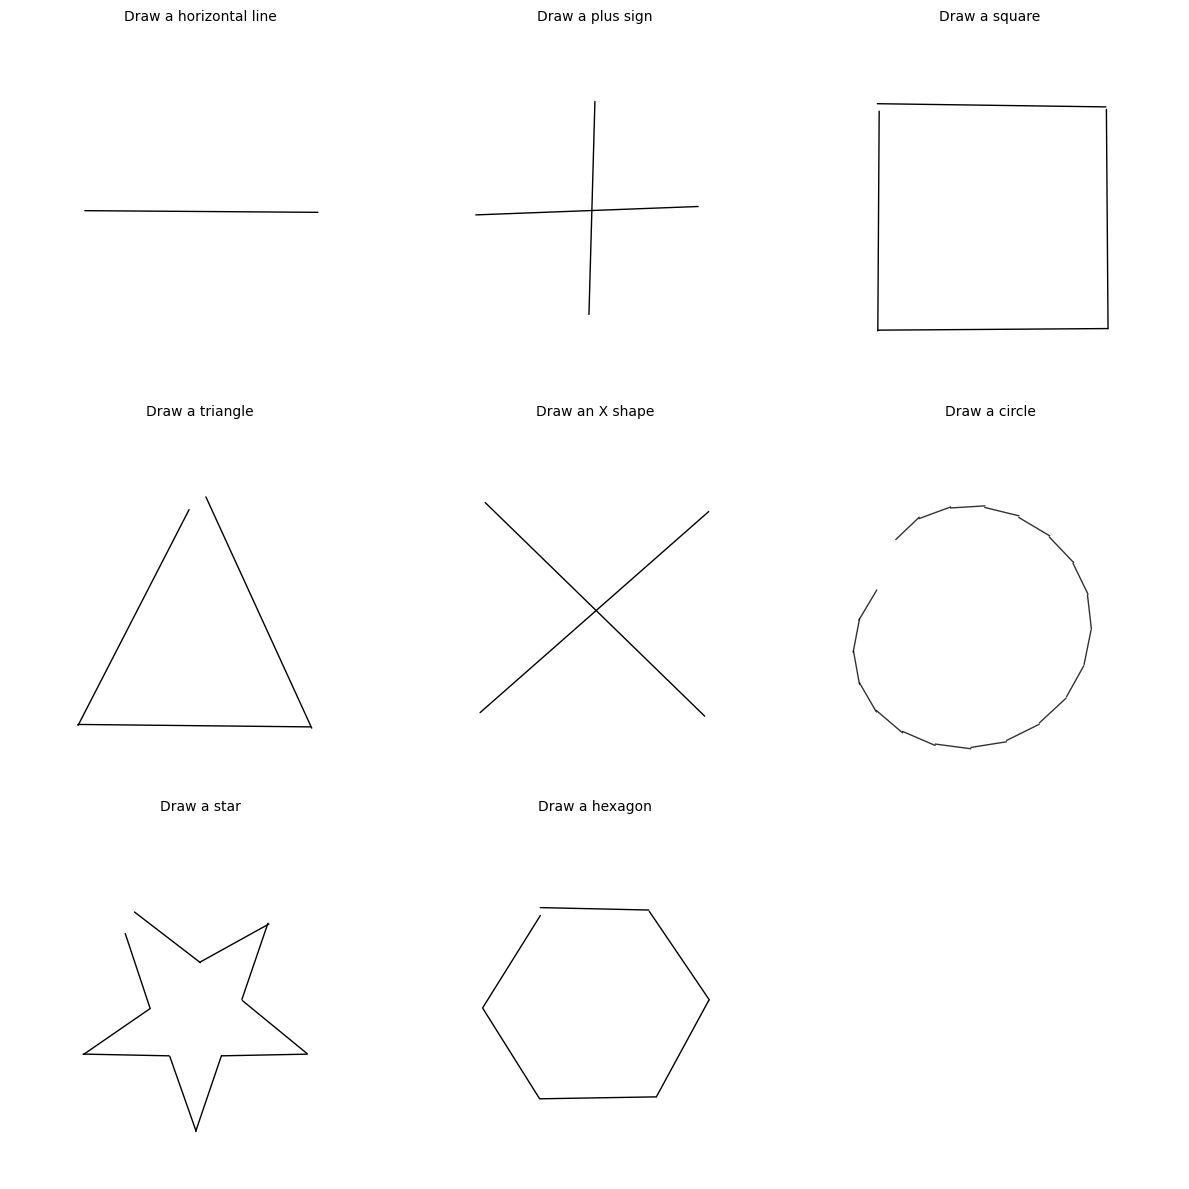

In [ ]:
import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np
from dcm import DeltaContinuousModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {device} with {num_gpus} GPU(s) available.")


# ==========================================
# 1. SYNTHETIC VECTOR DATASET GENERATOR
# ==========================================
def generate_circle(cx=0.5, cy=0.5, r=0.3, segments=20, t=0.03, a=0.8):
    strokes = []
    for i in range(segments):
        theta1 = 2 * math.pi * i / segments
        theta2 = 2 * math.pi * (i + 1) / segments
        x1, y1 = cx + r * math.cos(theta1), cy + r * math.sin(theta1)
        x2, y2 = cx + r * math.cos(theta2), cy + r * math.sin(theta2)
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_polygon(n_sides, cx=0.5, cy=0.5, r=0.3, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(n_sides):
        theta = 2 * math.pi * i / n_sides
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(n_sides):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n_sides]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_star(cx=0.5, cy=0.5, r_outer=0.3, r_inner=0.12, t=0.03, a=0.9):
    strokes = []
    points = []
    for i in range(10):
        r = r_outer if i % 2 == 0 else r_inner
        theta = math.pi / 2 + i * math.pi / 5
        x, y = cx + r * math.cos(theta), cy + r * math.sin(theta)
        points.append((x, y))
    for i in range(10):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % 10]
        strokes.append([x1, y1, x2, y2, t, a])
    return strokes


def generate_perfect_synthetic_dataset(filepath="overfit_dataset.json"):
    t = 0.05
    a = 1.0
    data = [
        {"prompt": "Draw a horizontal line", "strokes": [[0.2, 0.5, 0.8, 0.5, t, a]]},
        {
            "prompt": "Draw a plus sign",
            "strokes": [[0.5, 0.2, 0.5, 0.8, t, a], [0.2, 0.5, 0.8, 0.5, t, a]],
        },
        {
            "prompt": "Draw a square",
            "strokes": [
                [0.2, 0.2, 0.8, 0.2, t, a],
                [0.8, 0.2, 0.8, 0.8, t, a],
                [0.8, 0.8, 0.2, 0.8, t, a],
                [0.2, 0.8, 0.2, 0.2, t, a],
            ],
        },
        {
            "prompt": "Draw a triangle",
            "strokes": [
                [0.5, 0.2, 0.8, 0.8, t, a],
                [0.8, 0.8, 0.2, 0.8, t, a],
                [0.2, 0.8, 0.5, 0.2, t, a],
            ],
        },
        {
            "prompt": "Draw an X shape",
            "strokes": [[0.2, 0.2, 0.8, 0.8, t, a], [0.8, 0.2, 0.2, 0.8, t, a]],
        },
        {"prompt": "Draw a circle", "strokes": generate_circle()},
        {"prompt": "Draw a star", "strokes": generate_star(t=t, a=a)},
        {"prompt": "Draw a hexagon", "strokes": generate_polygon(6, t=t, a=a)},
    ]
    with open(filepath, "w") as f:
        json.dump(data, f, indent=4)


# ==========================================
# 2. CONTINUOUS & RELATIVE DATASET PIPELINE
# ==========================================
class OverfitStrokeDataset(Dataset):
    def __init__(self, json_path, max_seq_len=20):
        with open(json_path, "r") as f:
            self.data = json.load(f)
        self.max_seq_len = max_seq_len

        all_rel_strokes = []
        self.processed_data = []

        for item in self.data:
            strokes = torch.tensor(item["strokes"], dtype=torch.float32)
            strokes = self.sort_strokes_greedily(strokes)
            rel_strokes = self.to_relative(strokes)

            all_rel_strokes.append(rel_strokes)
            self.processed_data.append((item["prompt"], rel_strokes))

        # FIX: Calculate Z-Score Normalization Statistics
        concat_strokes = torch.cat(all_rel_strokes, dim=0)
        self.mean = concat_strokes.mean(dim=0)
        self.std = concat_strokes.std(dim=0) + 1e-6

    def sort_strokes_greedily(self, strokes):
        """FIX: Sorts strokes to maintain a continuous, physical drawing path."""
        if len(strokes) <= 1:
            return strokes

        # Start top-left
        dists_to_origin = strokes[:, 0] ** 2 + strokes[:, 1] ** 2
        start_idx = torch.argmin(dists_to_origin).item()

        unvisited = list(range(len(strokes)))
        sorted_strokes = []

        curr_idx = start_idx
        while unvisited:
            unvisited.remove(curr_idx)
            sorted_strokes.append(strokes[curr_idx])
            if not unvisited:
                break

            curr_end_x, curr_end_y = strokes[curr_idx][2], strokes[curr_idx][3]
            best_dist = float("inf")
            next_idx = unvisited[0]

            # Find the unvisited stroke closest to the current pen position
            for idx in unvisited:
                sx, sy = strokes[idx][0], strokes[idx][1]
                dist = (sx - curr_end_x) ** 2 + (sy - curr_end_y) ** 2
                if dist < best_dist:
                    best_dist = dist
                    next_idx = idx
            curr_idx = next_idx

        return torch.stack(sorted_strokes)

    def to_relative(self, strokes):
        """FIX: Convert Absolute Coordinates to Relative Offsets"""
        rel_strokes = torch.zeros_like(strokes)
        prev_x, prev_y = 0.0, 0.0
        for i in range(len(strokes)):
            x1, y1, x2, y2, w, a = strokes[i]
            dx1 = x1 - prev_x
            dy1 = y1 - prev_y
            dx2 = x2 - x1
            dy2 = y2 - y1
            rel_strokes[i] = torch.tensor([dx1, dy1, dx2, dy2, w, a])
            prev_x, prev_y = x2, y2
        return rel_strokes

    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        prompt, rel_strokes = self.processed_data[idx]

        # Apply Normalization
        norm_strokes = (rel_strokes - self.mean) / self.std

        if norm_strokes.shape[0] > self.max_seq_len:
            norm_strokes = norm_strokes[: self.max_seq_len]
        elif norm_strokes.shape[0] < self.max_seq_len:
            pad_len = self.max_seq_len - norm_strokes.shape[0]
            dead_stroke = -self.mean / self.std
            padding = dead_stroke.repeat(pad_len, 1)
            # padding = torch.zeros((pad_len, 6), dtype=torch.float32) # this is not 0
            norm_strokes = torch.cat([norm_strokes, padding], dim=0)

        return prompt, norm_strokes


def to_absolute(rel_strokes):
    """Utility to convert relative deltas back to canvas coordinates."""
    abs_strokes = torch.zeros_like(rel_strokes)
    prev_x, prev_y = 0.0, 0.0
    for i in range(len(rel_strokes)):
        dx1, dy1, dx2, dy2, w, a = rel_strokes[i]
        x1 = prev_x + dx1
        y1 = prev_y + dy1
        x2 = x1 + dx2
        y2 = y1 + dy2
        abs_strokes[i] = torch.tensor([x1, y1, x2, y2, w, a])
        prev_x, prev_y = x2, y2
    return abs_strokes


# ==========================================
# 3. OVERFIT TRAINING LOOP
# ==========================================
def train_overfit(model, dataloader, epochs=1000):
    # FIX: Swap MSE for L1 Loss to prevent averaging geometric uncertainty
    criterion = nn.L1Loss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4
    )
    scaler = GradScaler()

    model.train()
    print("Beginning 1,000-Epoch Sanity Overfit with L1 & Z-Score Normalization...")

    for epoch in range(epochs):
        optimizer.zero_grad()
        total_loss = 0.0

        for prompts, targets in dataloader:
            targets = targets.to(device)

            with autocast():
                predictions = model(prompts, targets)
                loss = criterion(predictions, targets)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1:04d}/{epochs} | Overfit L1 Loss: {total_loss/len(dataloader):.6f}"
            )


# ==========================================
# 4. N x 3 GALLERY GENERATOR
# ==========================================
def generate_validation_gallery(model, dataset, prompts, max_strokes=20, cols=3):
    model.eval()

    # Handle DataParallel wrapping
    actual_model = model.module if isinstance(model, nn.DataParallel) else model

    rows = math.ceil(len(prompts) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    print("\nGenerating Validation Gallery...")

    # Load Normalization Stats to Device
    mean = dataset.mean.to(device)
    std = dataset.std.to(device)

    with torch.no_grad():
        for idx, prompt in enumerate(prompts):
            text_inputs = actual_model.tokenizer(
                [prompt], padding=True, return_tensors="pt"
            ).to(device)
            encoder_outputs = actual_model.text_encoder(**text_inputs)
            encoder_hidden_states = encoder_outputs.last_hidden_state

            cls_token = encoder_hidden_states[:, 0, :]
            context_embed = actual_model.text_projection(cls_token).unsqueeze(1)

            current_strokes = torch.zeros((1, 0, 6), device=device)

            for step in range(max_strokes):
                if current_strokes.size(1) > 0:
                    stroke_embeds = actual_model.stroke_embedding(current_strokes)
                    decoder_inputs = torch.cat([context_embed, stroke_embeds], dim=1)
                else:
                    decoder_inputs = context_embed

                decoder_inputs = actual_model.pos_encoder(decoder_inputs)
                tgt_mask = actual_model.generate_causal_mask(
                    decoder_inputs.size(1), device
                )

                hidden_states = actual_model.transformer_decoder(
                    tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
                )

                next_stroke_pred = actual_model.output_head(hidden_states[:, -1:, :])
                current_strokes = torch.cat([current_strokes, next_stroke_pred], dim=1)

            # Un-normalize & Convert Relatives to Absolutes
            unnormalized_strokes = (current_strokes.squeeze(0) * std) + mean
            generated_vectors = to_absolute(unnormalized_strokes.cpu()).numpy()

            ax = axes[idx]
            ax.set_xlim(0, 1)
            ax.set_ylim(1, 0)
            ax.set_title(prompt[:30], fontsize=10)

            for stroke in generated_vectors:
                x1, y1, x2, y2, thickness, opacity = stroke
                if opacity > 0.3:
                    lw = max(1.0, thickness * 15.0)
                    ax.plot(
                        [x1, x2],
                        [y1, y2],
                        color="black",
                        alpha=min(1.0, max(0.0, float(opacity))),
                        linewidth=lw,
                        solid_capstyle="round",
                    )
            ax.axis("off")

    for idx in range(len(prompts), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


# ==========================================
# 5. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    generate_perfect_synthetic_dataset()
    dataset = OverfitStrokeDataset("overfit_dataset.json", max_seq_len=20)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=False)

    model = DeltaContinuousModel().to(device)
    if num_gpus > 1:
        model = nn.DataParallel(model)

    train_overfit(model, dataloader, epochs=1500)

    test_prompts = [
        "Draw a horizontal line",
        "Draw a plus sign",
        "Draw a square",
        "Draw a triangle",
        "Draw an X shape",
        "Draw a circle",
        "Draw a star",
        "Draw a hexagon",
    ]
    generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)


Generating Validation Gallery...


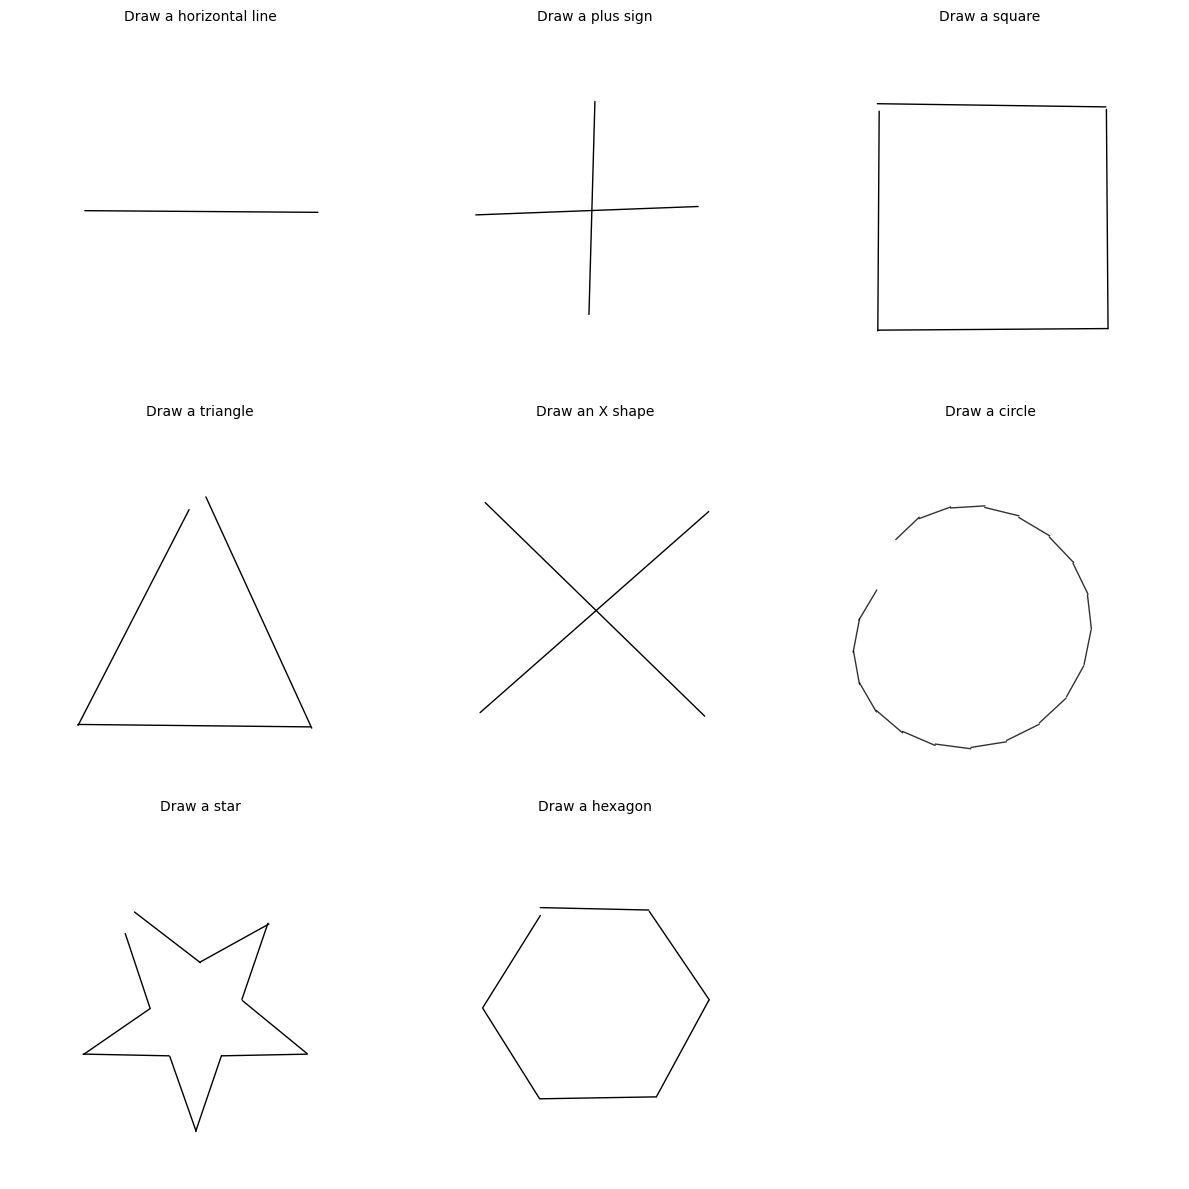

In [ ]:
generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)


Generating Validation Gallery...


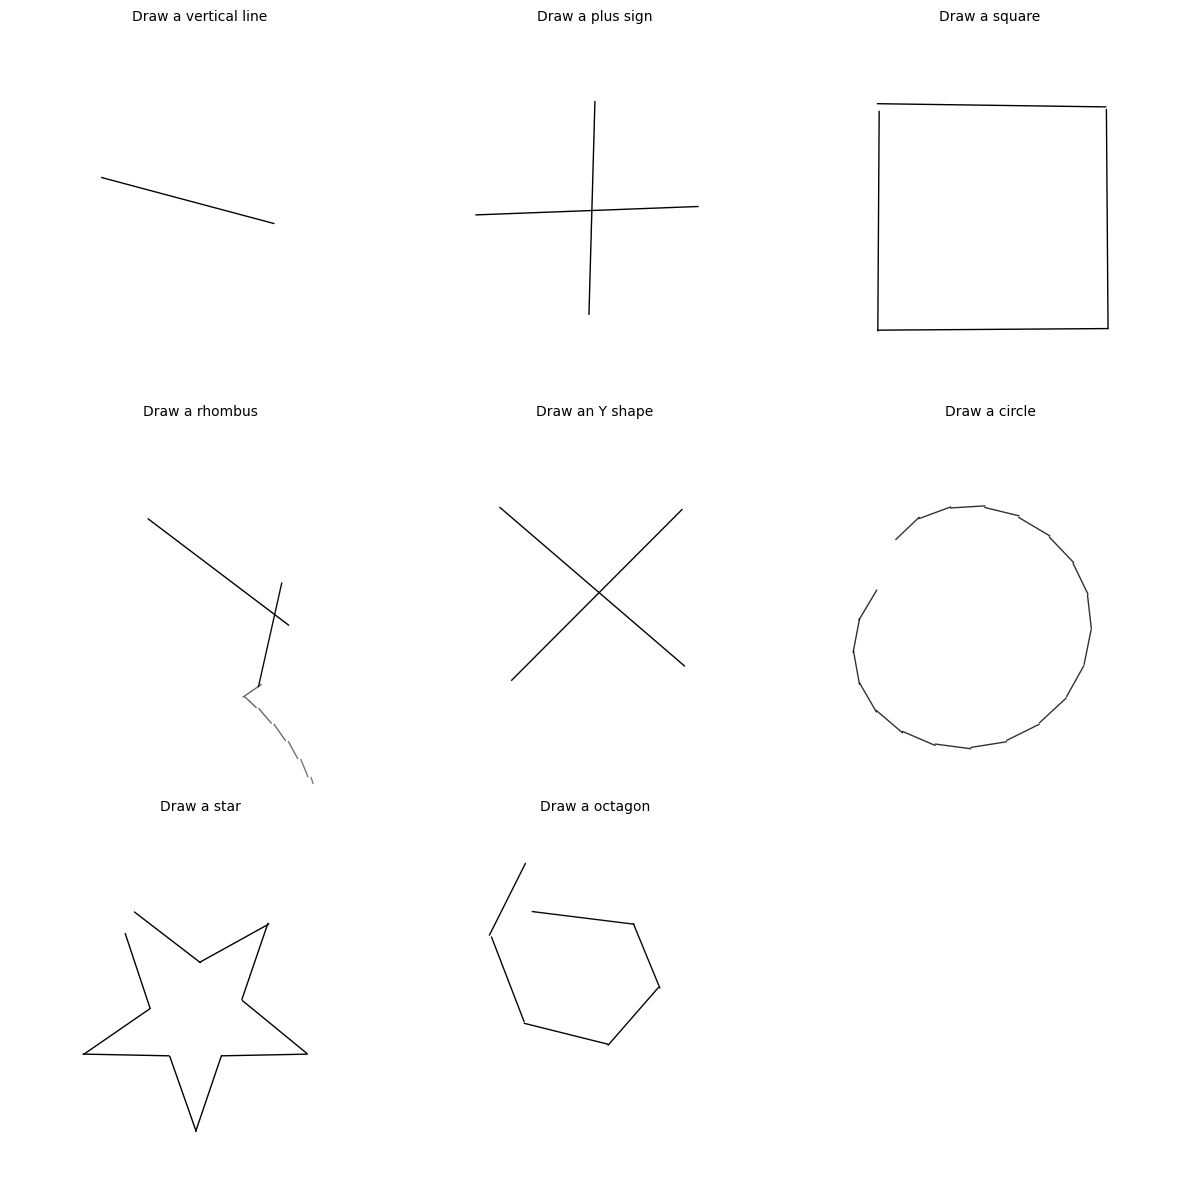

In [ ]:
test_prompts = [
        "Draw a vertical line",
        "Draw a plus sign",
        "Draw a square",
        "Draw a rhombus",
        "Draw an Y shape",
        "Draw a circle",
        "Draw a star",
        "Draw a octagon",
    ]
generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)


Generating Validation Gallery...


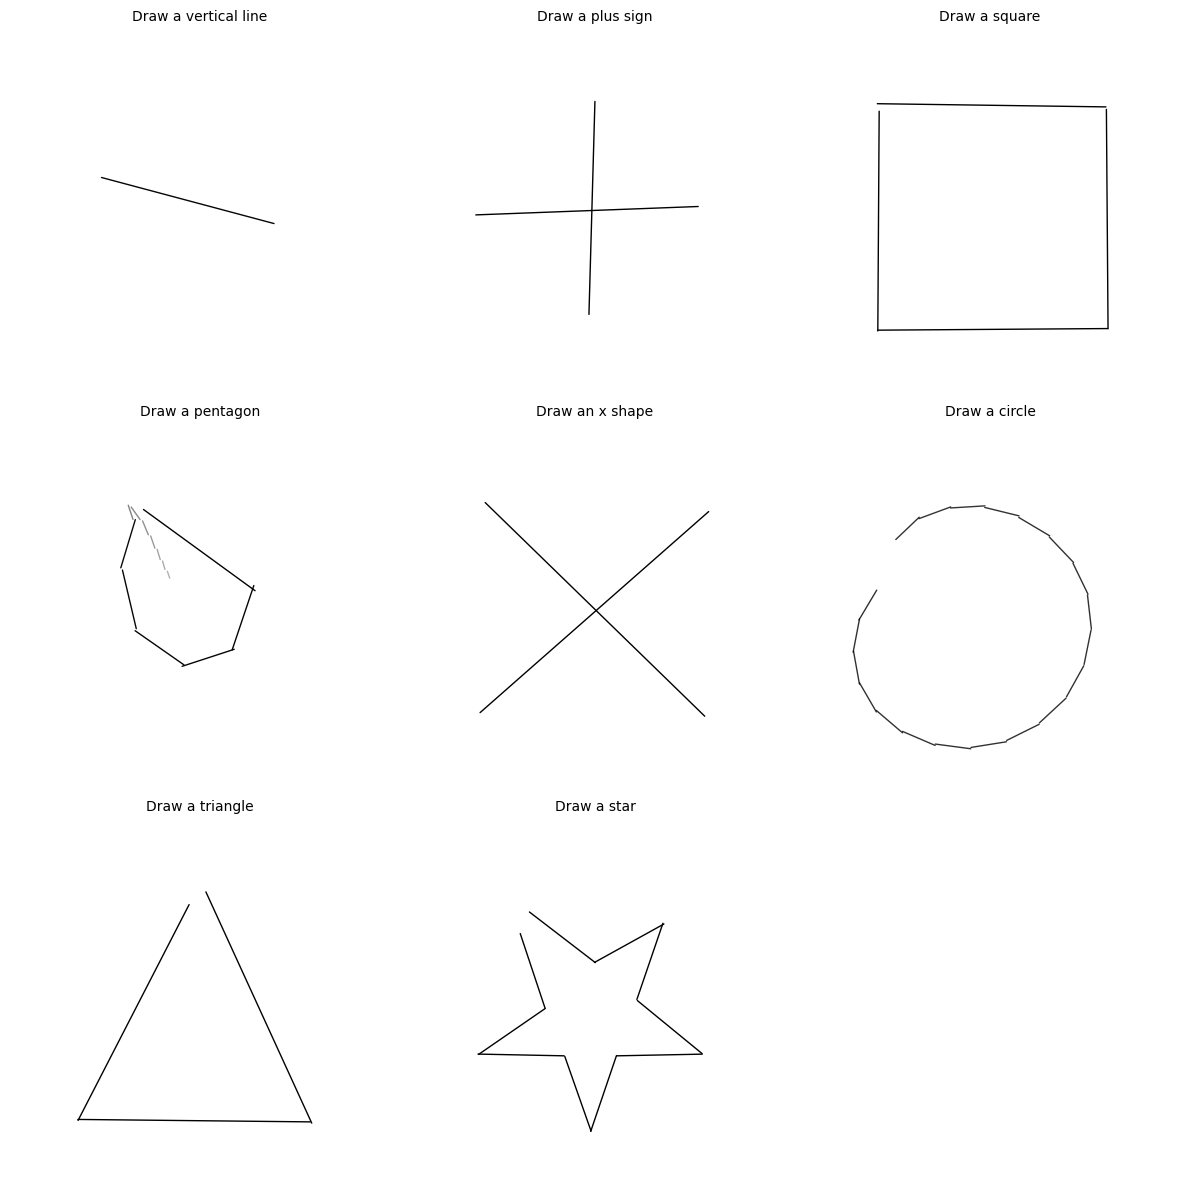

In [ ]:
test_prompts = [
        "Draw a vertical line",
        "Draw a plus sign",
        "Draw a square",
        "Draw a pentagon",
        "Draw an x shape",
        "Draw a circle",
        "Draw a triangle",
        "Draw a star",
    ]
generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)


Generating Validation Gallery...


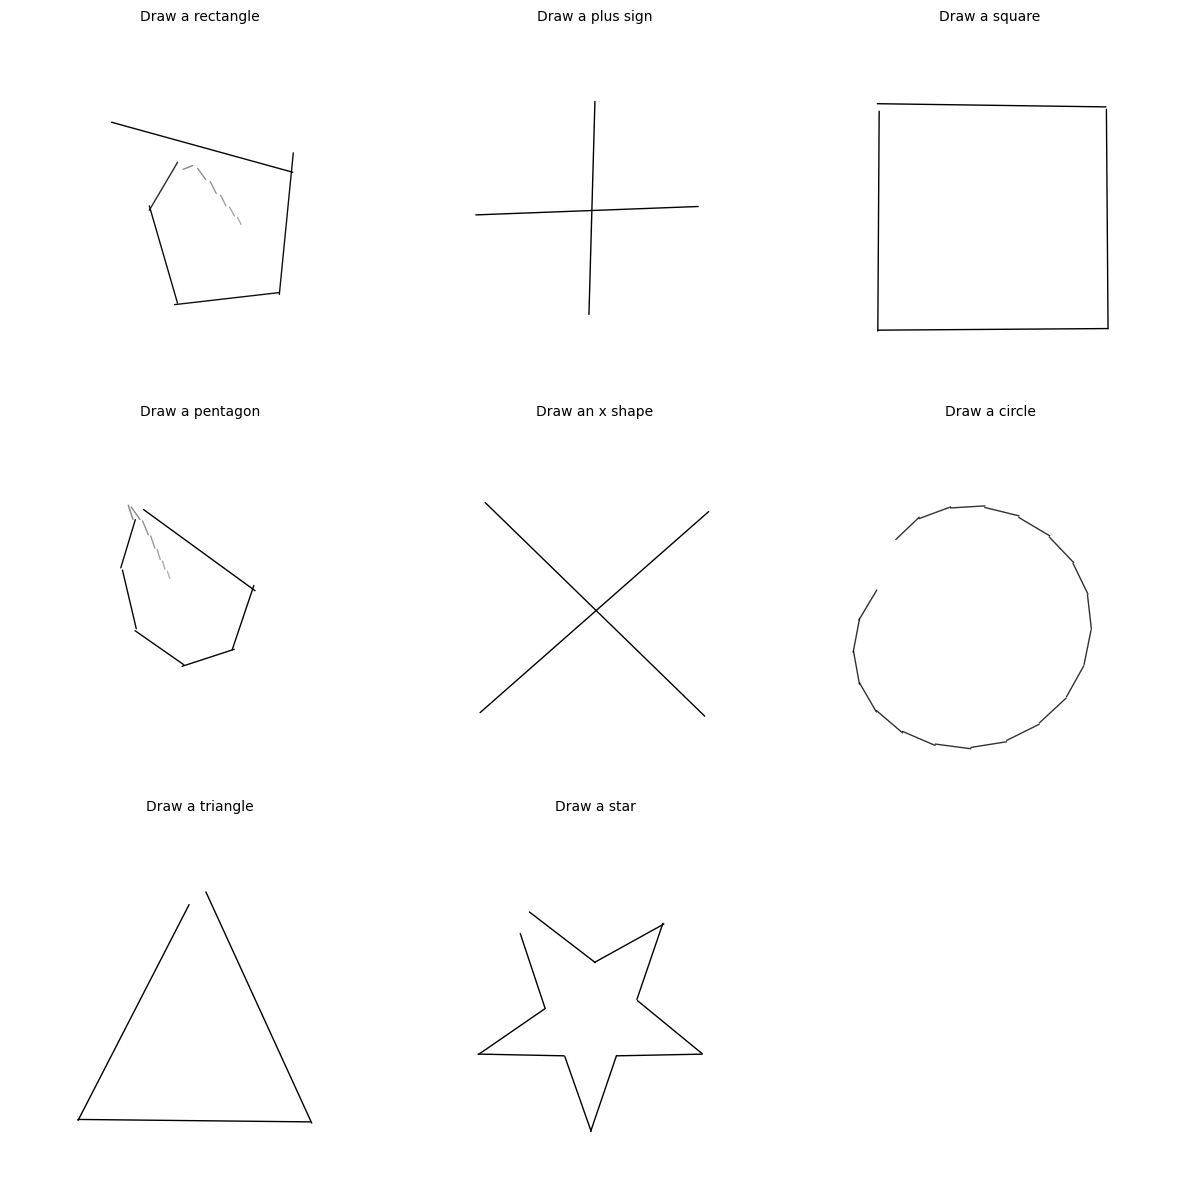

In [ ]:
test_prompts = [
        "Draw a rectangle",
        "Draw a plus sign",
        "Draw a square",
        "Draw a pentagon",
        "Draw an x shape",
        "Draw a circle",
        "Draw a triangle",
        "Draw a star",
    ]
generate_validation_gallery(model, dataset, test_prompts, max_strokes=20, cols=3)

No kernel connected